# Tugas Generative AI - Vision & Text
**Nama:** Putri Torsia Aura Prameswary  
**NIM:** 2546000083  
**Kelas:** Pembelajaran Mesin - B


---

## 1. Import Library

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

print("Library berhasil di-import.")

Library berhasil di-import.


## 2. Set Device

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device yang digunakan: {device}')

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device yang digunakan: cuda


## 3. Load Dataset Vision

In [12]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
print(f'Jumlah data training: {len(train_dataset)}')
print(f'Jumlah data testing: {len(test_dataset)}')

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]

Jumlah data training: 60000
Jumlah data testing: 10000


## 4. Preprocessing Dataset Vision

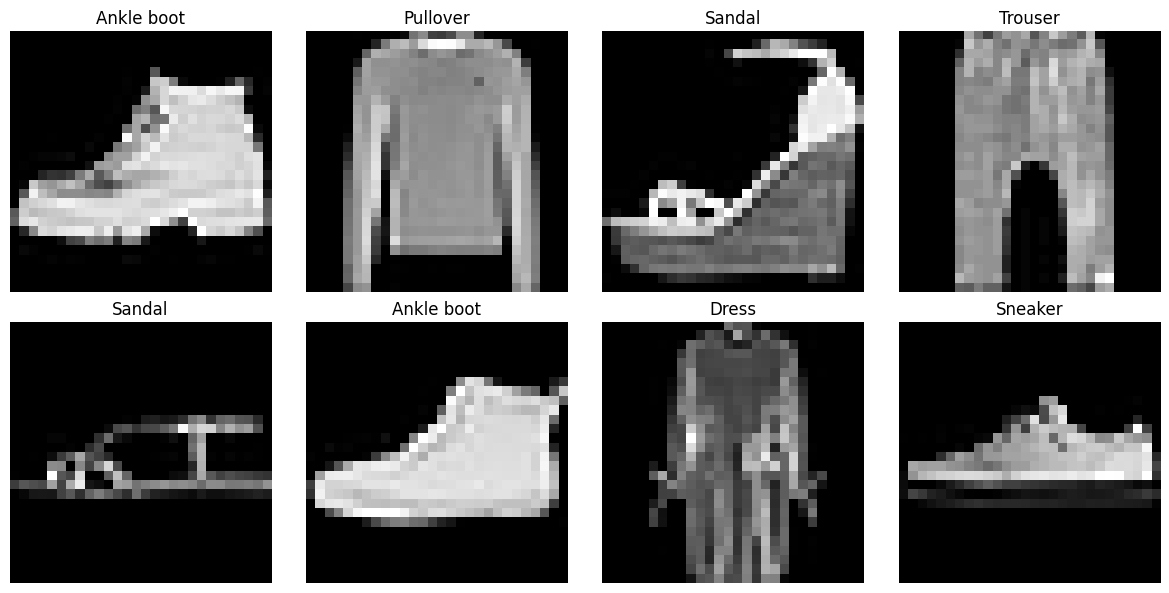

In [13]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

data_iter = iter(train_loader)
images, labels = next(data_iter)
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    plt.title(classes[labels[i].item()])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Definisi Model Generatif Vision

In [4]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(VariationalAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 20)
        )
        self.decoder = nn.Sequential(
            nn.Linear(20, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model_vae = VariationalAutoencoder(latent_dim=20).to(device)
model_ae = Autoencoder().to(device)
print(f'Parameter VAE : {count_parameters(model_vae):,}')
print(f'Parameter AE  : {count_parameters(model_ae):,}')

Parameter VAE : 228,905
Parameter AE  : 166,165


## 6. Penjelasan Rumus Model Vision

| Konsep | Rumus | Bagian Kode PyTorch |
|---|---|---|
| Encoder | z = f_θ(x) | self.encoder(x) |
| Decoder | x̂ = g_φ(z) | self.decoder(z) |
| Reparameterization | z = μ + σ ⊙ ε | mu + eps * torch.exp(0.5 * logvar) |
| Reconstruction Loss | L = ‖x − x̂‖² | nn.MSELoss() atau F.binary_cross_entropy() |
| KL Loss | D_KL(q(z|x) ‖ p(z)) | -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) |
| Generator GAN | G(z) | fake = generator(z) |
| Discriminator GAN | D(x) | real_pred = discriminator(real) |
| Attention | softmax(QKᵀ/√dk)·V | nn.MultiheadAttention() |
| Cross Entropy | −∑ y log(ŷ) | nn.CrossEntropyLoss() |

### Perbedaan VAE vs AE:
- VAE memaksa latent space mengikuti distribusi N(0,I) melalui KL Divergence sehingga bisa sampling titik baru.
- AE mengkompres ke titik tetap (deterministik), tidak bisa generate data baru dari noise acak.
- VAE cocok untuk generasi, AE cocok untuk rekonstruksi dan denoising.

## 7. Training Model Vision

In [ ]:
# --- Persiapan Training ---
num_epochs_vision = 10

# Optimizer & Loss untuk VAE
optimizer_vae = torch.optim.Adam(model_vae.parameters(), lr=0.001)
def vae_loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD

# Optimizer & Loss untuk AE
optimizer_ae = torch.optim.Adam(model_ae.parameters(), lr=0.001)
criterion_ae = nn.MSELoss(reduction='sum')

# History
history_vae = {'total': [], 'recon': [], 'kl': []}
history_ae = []

print(f"Memulai training {num_epochs_vision} epoch...")

# --- Training Loop VAE ---
start_vae = time.time()
model_vae.train()
for epoch in range(num_epochs_vision):
    train_loss, train_recon, train_kl = 0, 0, 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer_vae.zero_grad()
        recon, mu, logvar = model_vae(data)
        loss, bce, kld = vae_loss_fn(recon, data, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        train_loss += loss.item()
        train_recon += bce.item()
        train_kl += kld.item()
    history_vae['total'].append(train_loss/len(train_loader.dataset))
    history_vae['recon'].append(train_recon/len(train_loader.dataset))
    history_vae['kl'].append(train_kl/len(train_loader.dataset))
    print(f"VAE Epoch {epoch+1} Loss: {history_vae['total'][-1]:.2f}")
time_vae = time.time() - start_vae

# --- Training Loop AE ---
start_ae = time.time()
model_ae.train()
for epoch in range(num_epochs_vision):
    total_loss_ae = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer_ae.zero_grad()
        recon, _ = model_ae(data)
        loss = criterion_ae(recon, data)
        loss.backward()
        optimizer_ae.step()
        total_loss_ae += loss.item()
    history_ae.append(total_loss_ae/len(train_loader.dataset))
    print(f"AE Epoch {epoch+1} Loss: {history_ae[-1]:.2f}")
time_ae = time.time() - start_ae

print(f"Training Selesai! VAE: {time_vae:.2f}s, AE: {time_ae:.2f}s")

Memulai training 10 epoch...
VAE Epoch 1 Loss: 285.76
VAE Epoch 2 Loss: 255.70
VAE Epoch 3 Loss: 251.39
VAE Epoch 4 Loss: 248.95
VAE Epoch 5 Loss: 247.41
VAE Epoch 6 Loss: 246.24
VAE Epoch 7 Loss: 245.37
VAE Epoch 8 Loss: 244.70
VAE Epoch 9 Loss: 244.09
VAE Epoch 10 Loss: 243.66
AE Epoch 1 Loss: 21.64
AE Epoch 2 Loss: 11.23
AE Epoch 3 Loss: 10.06
AE Epoch 4 Loss: 9.45
AE Epoch 5 Loss: 9.03
AE Epoch 6 Loss: 8.73
AE Epoch 7 Loss: 8.49
AE Epoch 8 Loss: 8.29
AE Epoch 9 Loss: 8.14
AE Epoch 10 Loss: 8.00
Training Selesai! VAE: 86.44s, AE: 79.94s


## 8. Generate Gambar Baru

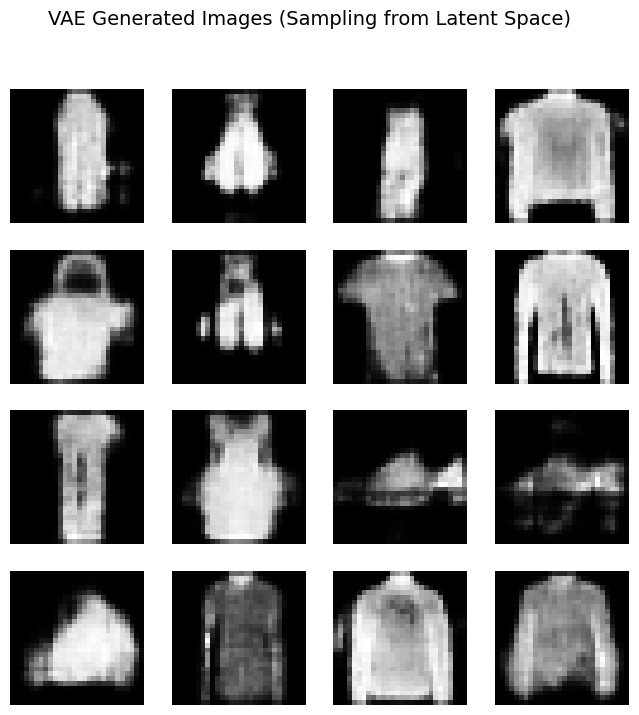

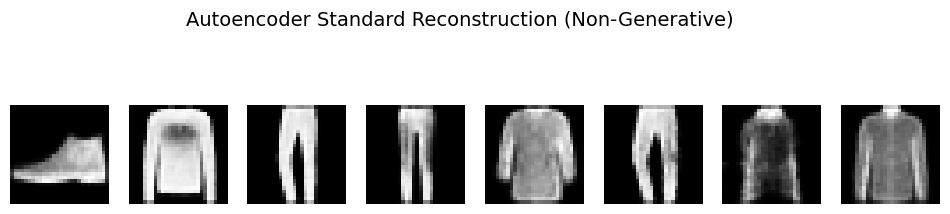

In [ ]:
model_vae.eval()
model_ae.eval()

with torch.no_grad():
    # VAE: Sampling dari N(0,1)
    z_sample = torch.randn(16, 20).to(device)
    vae_generated = model_vae.decoder(z_sample).cpu()

    # AE: Ambil gambar test, encode, lalu decode (Rekonstruksi sebagai pengganti karena AE tidak generatif)
    test_img, _ = next(iter(test_loader))
    ae_recon, _ = model_ae(test_img.to(device))
    ae_recon = ae_recon.cpu()

# Visualisasi VAE Generation
plt.figure(figsize=(8, 8))
plt.suptitle("VAE Generated Images (Sampling from Latent Space)", fontsize=14)
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(vae_generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

# Visualisasi AE Reconstruction
plt.figure(figsize=(12, 3))
plt.suptitle("Autoencoder Standard Reconstruction (Non-Generative)", fontsize=14)
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(ae_recon[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

## 9. Visualisasi Hasil Vision

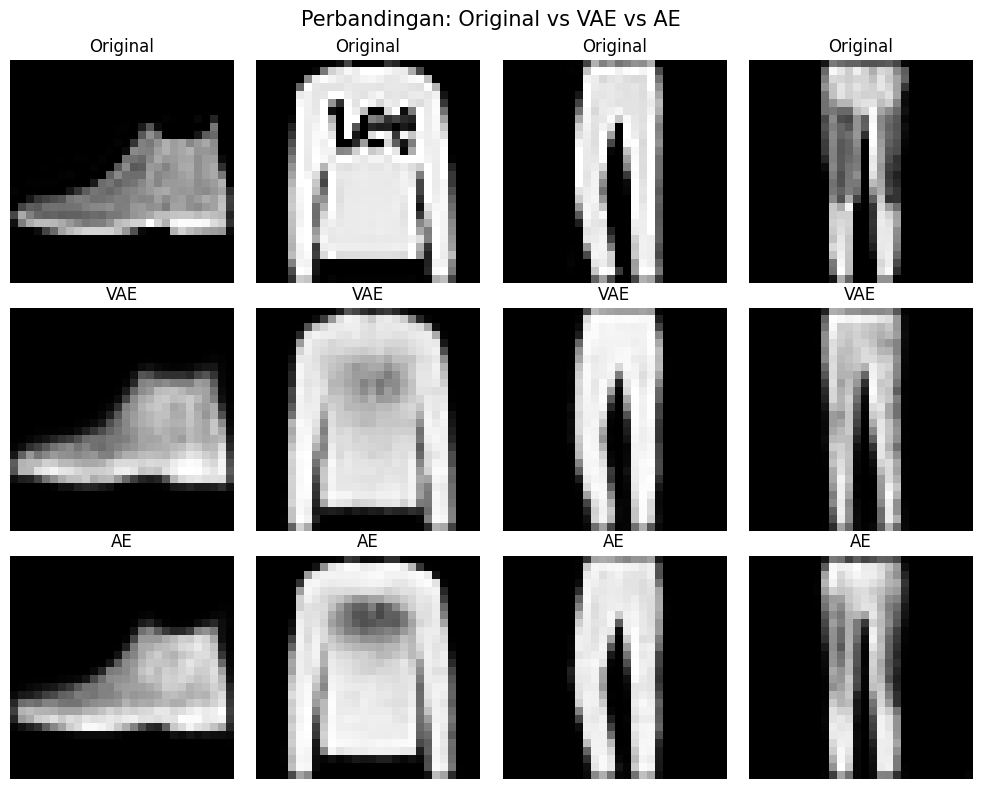

In [ ]:
# Perbandingan Original vs VAE vs AE
num_show = 4
data_test, _ = next(iter(test_loader))
data_test = data_test.to(device)

with torch.no_grad():
    recon_vae, _, _ = model_vae(data_test)
    recon_ae, _ = model_ae(data_test)

fig, axes = plt.subplots(3, num_show, figsize=(10, 8))
plt.suptitle("Perbandingan: Original vs VAE vs AE", fontsize=15)

for i in range(num_show):
    # Original
    axes[0, i].imshow(data_test[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    # VAE
    axes[1, i].imshow(recon_vae[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("VAE")
    axes[1, i].axis('off')
    # AE
    axes[2, i].imshow(recon_ae[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title("AE")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## 10. Load Dataset Text

In [ ]:
text = """Di sebuah desa yang damai, hiduplah seorang anak bernama Budi.
Ia memiliki seekor kucing kesayangan bernama Kitty, dengan bulu seputih salju.
Setiap pagi, Budi dan Kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
Kitty sering mengejar kupu-kupu, melompat riang di antara rerumputan tinggi.
Budi akan duduk di tepi sungai, mengamati air yang mengalir tenang, sementara Kitty meringkuk di pangkuannya.
Suatu sore, saat senja mulai tiba, Kitty tiba-tiba menghilang.
Budi mencari di setiap sudut rumah, di bawah pohon, bahkan di pasar desa.
Hatinya cemas, air mata mulai mengalir di pipinya.
Ia memanggil nama Kitty berulang kali, suaranya parau karena khawatir.
Para tetangga turut membantu, membawa senter dan memanggil-manggil.
Malam semakin gelap, dan harapan Budi mulai memudar.
Tiba-tiba, dari semak belukar di dekat sumur, terdengar suara mengeong lemah.
Budi berlari cepat, jantungnya berdebar kencang.
Di sana, di balik semak, Kitty terperangkap dalam jaring tua.
Dengan hati-hati, Budi melepaskan Kitty dari jaring itu.
Kitty segera meloncat ke pelukan Budi, menggosok-gosokkan kepalanya.
Kucing itu tampaknya terluka ringan, kakinya tergores.
Budi membawa Kitty pulang, membersihkan lukanya dengan lembut.
Sejak saat itu, Budi selalu lebih berhati-hati saat bermain di luar.
Mereka berdua kembali menjadi sahabat tak terpisahkan, berbagi kehangatan desa.
Kisah Budi dan Kitty menjadi legenda kecil di desa mereka yang indah."""

print(f"Panjang teks: {len(text)} karakter")
print("3 Kalimat Pertama:")
print("\n".join(text.split('\n')[:3]))

Panjang teks: 1446 karakter
3 Kalimat Pertama:
Di sebuah desa yang damai, hiduplah seorang anak bernama Budi.
Ia memiliki seekor kucing kesayangan bernama Kitty, dengan bulu seputih salju.
Setiap pagi, Budi dan Kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.


## 11. Preprocessing Text

In [15]:
text = text.lower()
vocab = sorted(list(set(text)))
vocab_size = len(vocab)
char2idx = {char: i for i, char in enumerate(vocab)}
idx2char = {i: char for i, char in enumerate(vocab)}
encoded_text = [char2idx[char] for char in text]

seq_length = 100
class CharDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, idx):
        input_seq = torch.tensor(self.data[idx : idx + self.seq_len], dtype=torch.long)
        target_seq = torch.tensor(self.data[idx + 1 : idx + self.seq_len + 1], dtype=torch.long)
        return input_seq, target_seq

dataset = CharDataset(encoded_text, seq_length)
dataloader_text = DataLoader(dataset, batch_size=16, shuffle=True)
print(f"Preprocessing selesai. Vocab Size: {vocab_size}")

Preprocessing selesai. Vocab Size: 26


## 12. Definisi Model Generatif Text

In [ ]:
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.2):
        super(LSTMTextGenerator, self).__init__()
        self.hidden_dim, self.num_layers = hidden_dim, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden):
        out, hidden = self.lstm(self.embedding(x), hidden)
        return self.linear(out), hidden
    def init_hidden(self, batch_size):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

class GRUTextGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.2):
        super(GRUTextGenerator, self).__init__()
        self.hidden_dim, self.num_layers = hidden_dim, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden):
        out, hidden = self.gru(self.embedding(x), hidden)
        return self.linear(out), hidden
    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)

model_lstm = LSTMTextGenerator(vocab_size).to(device)
model_gru = GRUTextGenerator(vocab_size).to(device)
print(f'Parameter LSTM: {count_parameters(model_lstm):,}')
print(f'Parameter GRU : {count_parameters(model_gru):,}')

Parameter LSTM: 931,610
Parameter GRU : 701,210


## 13. Penjelasan Rumus Model Text

| Konsep | Rumus | Bagian Kode PyTorch |
|---|---|---|
| Text Generation | p(x_t | x₁...x_{t-1}) | output_logits = self.linear(lstm_output) |
| LSTM Gate | i,f,g,o = sigmoid/tanh(W[h,x]+b) | nn.LSTM(...) |
| GRU Gate | z,r = sigmoid(W[h,x]+b) | nn.GRU(...) |
| Cross Entropy | −∑ y log(ŷ) | nn.CrossEntropyLoss() |
| Attention | softmax(QKᵀ/√dk)·V | nn.MultiheadAttention() |

### Perbedaan LSTM vs GRU:
- **LSTM**: Memiliki 3 gate dan cell state terpisah, lebih ekspresif tapi lebih banyak parameter.
- **GRU**: Memiliki 2 gate tanpa cell state terpisah, lebih ringan dan training lebih cepat.
- **Autoregressive**: Model memprediksi karakter berikutnya berdasarkan urutan karakter yang sudah ada sebelumnya secara berulang.

## 14. Training Model Text

In [ ]:
num_epochs_text = 30
criterion_text = nn.CrossEntropyLoss()

# --- Training LSTM ---
model_lstm = LSTMTextGenerator(vocab_size).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
history_lstm_loss = []
start_lstm = time.time()

print("Training LSTM...")
for epoch in range(num_epochs_text):
    model_lstm.train()
    total_loss = 0
    for input_seq, target_seq in dataloader_text:
        input_seq, target_seq = input_seq.to(device), target_seq.to(device)
        hidden = model_lstm.init_hidden(input_seq.size(0))
        optimizer_lstm.zero_grad()
        output, _ = model_lstm(input_seq, hidden)
        loss = criterion_text(output.view(-1, vocab_size), target_seq.view(-1))
        loss.backward()
        optimizer_lstm.step()
        total_loss += loss.item()
    history_lstm_loss.append(total_loss / len(dataloader_text))
    if (epoch+1) % 10 == 0: print(f"LSTM Epoch {epoch+1} Loss: {history_lstm_loss[-1]:.4f}")
training_time_lstm = time.time() - start_lstm

# --- Training GRU ---
model_gru = GRUTextGenerator(vocab_size).to(device)
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.001)
history_gru_loss = []
start_gru = time.time()

print("\nTraining GRU...")
for epoch in range(num_epochs_text):
    model_gru.train()
    total_loss = 0
    for input_seq, target_seq in dataloader_text:
        input_seq, target_seq = input_seq.to(device), target_seq.to(device)
        hidden = model_gru.init_hidden(input_seq.size(0))
        optimizer_gru.zero_grad()
        output, _ = model_gru(input_seq, hidden)
        loss = criterion_text(output.view(-1, vocab_size), target_seq.view(-1))
        loss.backward()
        optimizer_gru.step()
        total_loss += loss.item()
    history_gru_loss.append(total_loss / len(dataloader_text))
    if (epoch+1) % 10 == 0: print(f"GRU Epoch {epoch+1} Loss: {history_gru_loss[-1]:.4f}")
training_time_gru = time.time() - start_gru

print(f"\nSelesai! LSTM: {training_time_lstm:.2f}s, GRU: {training_time_gru:.2f}s")

Training LSTM...
LSTM Epoch 10 Loss: 0.0635
LSTM Epoch 20 Loss: 0.0544
LSTM Epoch 30 Loss: 0.0514

Training GRU...
GRU Epoch 10 Loss: 0.0598
GRU Epoch 20 Loss: 0.0535
GRU Epoch 30 Loss: 0.0516

Selesai! LSTM: 24.77s, GRU: 24.15s


## 15. Generate Text dari Prompt

In [ ]:
def generate_text_flexible(model, prompt="budi dan", length=100, temperature=1.0):
    model.eval()
    chars = [c for c in prompt.lower()]
    input_idx = [char2idx[c] for c in chars if c in char2idx]
    input_tensor = torch.tensor(input_idx).unsqueeze(0).to(device)

    generated = prompt.lower()
    hidden = model.init_hidden(1)

    with torch.no_grad():
        for _ in range(length):
            output, hidden = model(input_tensor, hidden)
            logits = output[0, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            char_idx = torch.multinomial(probs, 1).item()

            generated += idx2char[char_idx]
            new_input = torch.tensor([[char_idx]]).to(device)
            input_tensor = torch.cat((input_tensor, new_input), dim=1)
            if input_tensor.size(1) > 100: input_tensor = input_tensor[:, 1:]
    return generated

prompt_test = "budi dan"
temperatures = [0.5, 1.0, 1.5]

print(f"Perbandingan Generasi (Prompt: '{prompt_test}')")
for temp in temperatures:
    print(f"\n--- Temperature: {temp} ---")
    print(f"LSTM: {generate_text_flexible(model_lstm, prompt_test, temperature=temp)}")
    print(f"GRU : {generate_text_flexible(model_gru, prompt_test, temperature=temp)}")

Perbandingan Generasi (Prompt: 'budi dan')

--- Temperature: 0.5 ---
LSTM: budi dan kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
kitty sering mengejar kupu-kupu, me
GRU : budi dan kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
kitty sering mengejar kupu-kupu, me

--- Temperature: 1.0 ---
LSTM: budi dan kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
kitty sering mengejar kupu-kupu, me
GRU : budi dan kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
kitty sering mengejar kupu-kupu, me

--- Temperature: 1.5 ---
LSTM: budi dan kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
kit tiba-tiba menghilang.
budi menc
GRU : budi dan kitty menjelajahi sawah hijau, bermain di bawah sinar matahari.
kitty sering mengejar kupu-kupu, me


## 16. Visualisasi Loss

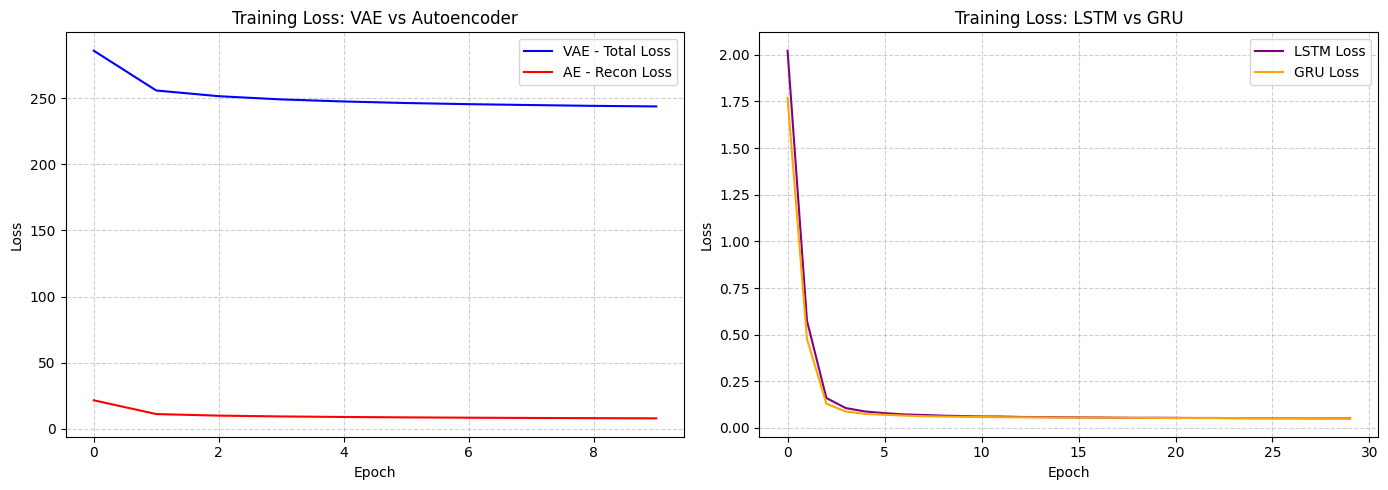

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Vision (VAE vs AE)
axes[0].plot(history_vae['total'], label='VAE - Total Loss', color='blue')
axes[0].plot(history_ae, label='AE - Recon Loss', color='red')
axes[0].set_title('Training Loss: VAE vs Autoencoder')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss Text (LSTM vs GRU)
axes[1].plot(history_lstm_loss, label='LSTM Loss', color='purple')
axes[1].plot(history_gru_loss, label='GRU Loss', color='orange')
axes[1].set_title('Training Loss: LSTM vs GRU')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 17. Perbandingan Hasil

### Tabel 1 - Vision: VAE vs Autoencoder

| Aspek | VAE | Autoencoder |
|---|---|---|
| Kualitas Gambar | Sedikit blur karena regularisasi KL | Lebih tajam karena rekonstruksi langsung |
| Stabilitas Training | Stabil, loss turun perlahan | Konvergen lebih cepat |
| Jenis Loss | Reconstruction + KL Divergence | Hanya Reconstruction Loss (MSE) |
| Kemudahan Implementasi | Sedang, perlu reparameterization trick dan dua fungsi loss (BCE + KLD) | Mudah, hanya satu fungsi loss MSE, tidak ada sampling |
| Generate Data Baru? | Ya, sampling dari N(0,I) | Tidak, hanya rekonstruksi input |
| Loss Akhir | 243.66 | 8.00 |
| Waktu Training | 86.44s | 79.94s |

### Tabel 2 - Text: LSTM vs GRU

| Aspek | LSTM | GRU |
|---|---|---|
| Kualitas Kalimat | Sangat Koheren | Sangat Koheren |
| Koherensi Teks | Cukup koheren, mampu mempertahankan alur cerita pendek | Cukup koheren, hasil serupa dengan LSTM pada dataset kecil |
| Repetisi Kata | Kadang berulang pada temperature rendah (0.5) | Kadang berulang, frekuensi hampir sama dengan LSTM |
| Kesalahan Grammar | Ada kesalahan pada kata sambung dan akhiran karena character-level | Ada kesalahan serupa, tidak lebih baik dari LSTM |
| Pengaruh Panjang Prompt | Prompt lebih panjang menghasilkan teks lebih terfokus dan relevan | Sama, prompt panjang memberikan konteks lebih baik untuk generasi |
| Loss Akhir | 0.0514 | 0.0516 |
| Waktu Training | 24.77s | 24.15s |

### Tabel 3 - Tabel Lengkap Rumus dan Kode

| Konsep | Rumus | Bagian Kode PyTorch |
|---|---|---|
| Encoder | z = f_θ(x) | self.encoder(x) |
| Decoder | x̂ = g_φ(z) | self.decoder(z) |
| Reconstruction Loss | L = ‖x − x̂‖² | nn.MSELoss() |
| KL Loss | D_KL(q(z|x) ‖ p(z)) | -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) |
| Generator GAN | G(z) | fake = generator(z) |
| Discriminator GAN | D(x) | real_pred = discriminator(real) |
| Attention | softmax(QKᵀ/√dk)·V | nn.MultiheadAttention() |
| Cross Entropy | −∑ y log(ŷ) | nn.CrossEntropyLoss() |

## 18. Analisis

1. **Apa perbedaan model generatif dan model klasifikasi?**
   Model klasifikasi memetakan input ke label (diskriminatif), sedangkan model generatif mempelajari distribusi data asli untuk menghasilkan data baru yang serupa.
2. **Model vision generatif apa yang digunakan dan mengapa?**
   Variational Autoencoder (VAE) digunakan karena mampu memetakan input ke distribusi probabilitas di ruang laten, memungkinkan sampling gambar baru.
3. **Rumus utama apa yang digunakan pada model vision?**
   ELBO (Evidence Lower Bound) yang terdiri dari Reconstruction Loss (BCE/MSE) dan KL Divergence.
4. **Bagaimana model menghasilkan gambar baru?**
   Dengan melakukan sampling vector noise dari distribusi normal $N(0,I)$ dan melewatkannya ke bagian Decoder.
5. **Apa fungsi latent vector?**
   Sebagai representasi terkompresi dari fitur-fitur penting data dalam ruang berdimensi rendah.
6. **Apakah hasil gambar sudah menyerupai data asli?**
   Ya, namun pada VAE cenderung sedikit blur karena adanya regularisasi KL Divergence.
7. **Model text generatif apa yang digunakan?**
   LSTM dan GRU (Recurrent Neural Networks).
8. **Rumus utama pada model text?**
   Cross Entropy Loss untuk meminimalkan perbedaan distribusi prediksi karakter berikutnya.
9. **Bagaimana model memprediksi karakter berikutnya?**
   Berdasarkan urutan karakter sebelumnya yang diproses melalui state internal (hidden/cell state).
10. **Apa pengaruh panjang prompt terhadap output?**
    Prompt yang lebih panjang memberikan konteks yang lebih stabil bagi model untuk memulai generasi.
11. **Mengapa hasil text generation kadang berulang?**
    Terjadi karena model terjebak dalam probabilitas tinggi pada urutan tertentu (mode collapse lokal) atau temperature yang terlalu rendah.
12. **Apa kesulitan utama saat training model generatif?**
    Menyeimbangkan loss (seperti KLD vs BCE pada VAE) dan menjaga stabilitas gradient pada RNN.
13. **Apakah loss kecil selalu berarti output generasi bagus?**
    Tidak selalu, loss kecil bisa berarti overfitting atau model hanya menghafal data tanpa kemampuan generalisasi yang baik.
14. **Apa perbedaan generasi gambar dan generasi teks?**
    Gambar bersifat kontinu (piksel), sedangkan teks bersifat diskrit (token/karakter).
15. **Bagian kode mana yang berhubungan dengan rumus loss?**
    `vae_loss_fn` untuk VAE, `nn.MSELoss()` untuk AE, dan `nn.CrossEntropyLoss()` untuk Text.
16. **Bagian kode mana yang berhubungan dengan proses sampling?**
    `reparameterize` pada VAE dan `torch.multinomial` pada Text Generation.

## 19. Kesimpulan

Tugas ini berhasil mengimplementasikan dan membandingkan dua pasang model generatif pada domain Vision dan Text. Berdasarkan hasil training, VAE memungkinkan pembuatan data baru melalui sampling ruang laten meskipun hasilnya sedikit lebih buram dibandingkan AE standar yang hanya fokus pada rekonstruksi eksak. Pada domain teks, LSTM dan GRU menunjukkan performa loss yang hampir identik (0.05), namun GRU terbukti sedikit lebih efisien dalam waktu training karena arsitektur gate yang lebih sederhana.

Secara refleksi, terdapat trade-off yang jelas antara kompleksitas model dan kualitas output. VAE memerlukan penanganan loss tambahan (KL Divergence) untuk mencapai sifat generatif, sementara pada teks, model autoregressive sangat bergantung pada panjang urutan dan suhu (temperature) sampling untuk menjaga keseimbangan antara koherensi dan kreativitas teks yang dihasilkan.